# 3b — GBM Sweeps (v2.0)

Hyperparameter optimisation and feature analysis for the **Histogram Gradient Boosting Machine** (quantile regression).

| § | Stage | Description | Est. wall time |
|---|---|---|---|
| 2 | **Optuna HPO** | TPE 5-fold CV | 1–3 h |
| 3 | **Feature ablation** | LOO ΔR² with best params | ~30 min |
| 4 | **MC feature subset** | Random subset R² | 2–4 h |
| 5 | **Greedy forward** | Iterative best-feature build | 2–4 h |

Outputs → `output/sweeps/gbm_*.csv` | Figures → `fig/sweeps/gbm_*.png`

Best params written to `output/sweeps/gbm_params.json` (imported by `4_MODEL.ipynb`).

**Optuna search space:**  `max_iter` [100–800 step 50],  `max_depth` [3–10],  `learning_rate` [0.01–0.30 log],  `min_samples_leaf` [5–60],  `max_features` [0.3–1.0],  `l2_regularization` [0–5].  Warm-started from `config.py` defaults.

## 0. Toggles

In [ ]:
from config import N_OPTUNA_TRIALS, MC_N_RUNS  # config-derived defaults; kept self-sufficient so this cell can run first

RUN_GBM_OPTUNA    = True
RUN_GBM_ABLATION  = True
RUN_GBM_MC        = True
RUN_GBM_GREEDY    = True

GBM_N_OPTUNA_TRIALS = N_OPTUNA_TRIALS
GBM_CALIBRATION_FRAC = 0.20
GBM_MC_N_RUNS       = MC_N_RUNS
GBM_MC_MIN_FEATS    = 5
GBM_MC_MAX_FEATS    = None
GBM_RANDOM_SEED     = 2026
GBM_MC_SEED         = 2025
GBM_GREEDY_SEED     = 2025
GBM_QUANTILES       = [0.05, 0.50, 0.95]

✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36


## 1. Imports & setup

In [16]:
import sys, json, time, warnings, platform, psutil, datetime
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from pathlib import Path
from sklearn.model_selection import train_test_split, KFold
from lib.similarity import spatial_block_kfold  # v0_5 #6: spatial CV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from joblib import Parallel, delayed

from config import *

optuna.logging.set_verbosity(optuna.logging.WARNING)

sweep_dir.mkdir(parents=True, exist_ok=True)
(fig_root / 'sweeps').mkdir(parents=True, exist_ok=True)
fig_sweep = fig_root / 'sweeps'

print(f"sweep_dir : {sweep_dir}")
print(f"fig_sweep : {fig_sweep}")
from sklearn.ensemble import HistGradientBoostingRegressor


sweep_dir : output/sweeps
fig_sweep : fig/sweeps


### 1a. Verify parquet

In [ ]:
df_check = pd.read_parquet(parquet_ref, columns=obs_model + ['q'])
missing_m = [c for c in obs_model if c not in df_check.columns]
all_nan_m = [c for c in obs_model if df_check[c].isna().all()]
assert not missing_m, f'MISSING from parquet: {missing_m}'
assert not all_nan_m, f'ALL-NaN columns: {all_nan_m}'
print(f'\u2713 {len(obs_model)} obs_model features verified | q_clip_max={q_clip_max}')

✓ 21 obs_model features verified | q_clip_max=0.35


### 1b. Load reference data

In [18]:
# obs_sel here = the CANDIDATE feature universe fed into the sweep (edit to test a
# different universe). The FINAL selected subset is written to the sweep JSON under
# the 'obs_sel' key and is what 4x/5x load — this line does not set the final list.
obs_sel = obs_sweep

df_ref    = pd.read_parquet(parquet_ref)
available = [f for f in obs_sel if f in df_ref.columns]
missing   = [f for f in obs_sel if f not in df_ref.columns]
if missing:
    warnings.warn(f'obs_sel columns missing from parquet: {missing}')
    raise RuntimeError(f'Missing features: {missing}')

cols_needed = available + ['q', 'lat', 'lon']  # v0_5 #6: lat/lon for spatial CV
if 'weight' in df_ref.columns:
    cols_needed.append('weight')

work = (df_ref[cols_needed]
        .replace([np.inf, -np.inf], np.nan)
        .dropna())
work = work[(work['q'] >= q_clip_min) & (work['q'] <= q_clip_max)]

y_phys = work['q'].values
w_all  = work['weight'].values if 'weight' in work.columns else np.ones(len(work))
X_all  = work[available].values
lat_all = work['lat'].values  # v0_5 #6: for spatial_block_kfold
lon_all = work['lon'].values

print(f'Reference rows : {len(work):,}')
print(f'Features       : {len(available)}')
print(available)


Reference rows : 30,847
Features       : 22
['BOUGUER', 'CTD', 'MOHO', 'REVEAL_S80', 'LITH_RHO', 'REVEAL_S70', 'MAG_SEIS_MOHO', 'REVEAL_VP90VS60', 'CRUST_RHO', 'DEM', 'SI', 'GEOID', 'LAB', 'REVEAL_VP60VS70', 'SEDIMENT', 'REVEAL_P150', 'EMAG2_LOG', 'FREE_AIR', 'REVEAL_S90', 'REVEAL_S100', 'REVEAL_VP50VS80', 'MOHO_GRAV']


### 1c. Train / calibration split + StandardScaler

In [19]:
# v0_5 #6: derive the single train/cal split from the FIRST spatial block fold
# instead of a random train_test_split. A random hold-out shares the same
# spatial-autocorrelation leakage as random KFold; a spatial fold gives an
# honest calibration estimate. Fold sizes are ~1/n_splits, comparable to the
# previous GBM_CALIBRATION_FRAC hold-out.
_gbm_folds = spatial_block_kfold(lat_all, lon_all,
                                 n_splits=N_CV_FOLDS, random_state=random_state)
_tr_idx, _cal_idx = _gbm_folds[0]
X_train, X_cal          = X_all[_tr_idx],  X_all[_cal_idx]
y_train_phys, y_cal_phys = y_phys[_tr_idx], y_phys[_cal_idx]
w_train                 = w_all[_tr_idx]
sc_gbm  = StandardScaler()
X_tr_s  = sc_gbm.fit_transform(X_train)
X_cal_s = sc_gbm.transform(X_cal)
print(f'Train : {len(X_train):,}   Cal : {len(X_cal):,}')


Train : 24,770   Cal : 6,077


### 1d. Evaluation helper + baseline

In [20]:
def _gbm_eval(feat_idx, params):
    Xtr = X_tr_s[:, feat_idx];  Xca = X_cal_s[:, feat_idx]
    preds = {}
    t0 = time.time()
    for q in GBM_QUANTILES:
        mdl = HistGradientBoostingRegressor(
            loss='quantile', quantile=q,
            max_iter         =int(params.get('max_iter',         GB_MAX_ITER)),
            max_depth        =int(params.get('max_depth',        GB_MAX_DEPTH)),
            learning_rate    =float(params.get('learning_rate',  GB_LEARNING_RATE)),
            min_samples_leaf =int(params.get('min_samples_leaf', GB_MIN_SAMPLES_LEAF)),
            max_features     =float(params.get('max_features',   GB_MAX_FEATURES)),
            l2_regularization=float(params.get('l2_regularization', GB_L2_REG)),
            random_state=random_state)
        mdl.fit(Xtr, y_train_phys, sample_weight=w_train)
        preds[q] = np.clip(mdl.predict(Xca), q_clip_min, q_clip_max)
    p05, p50, p95 = preds[0.05], preds[0.50], preds[0.95]
    return dict(
        r2  =float(r2_score(y_cal_phys, p50)),
        rmse=float(np.sqrt(mean_squared_error(y_cal_phys, p50))),
        picp=float(np.mean((y_cal_phys >= p05) & (y_cal_phys <= p95))),
        elapsed_s=time.time()-t0)

DEFAULT_GBM = dict(max_iter=GB_MAX_ITER, max_depth=GB_MAX_DEPTH,
    learning_rate=GB_LEARNING_RATE, min_samples_leaf=GB_MIN_SAMPLES_LEAF,
    max_features=GB_MAX_FEATURES, l2_regularization=GB_L2_REG)

all_idx = list(range(len(available)))
print('Training GBM baseline (default params)...')
gbm_baseline = _gbm_eval(all_idx, DEFAULT_GBM)
gbm_base_r2  = gbm_baseline['r2']
print(f'  RMSE={gbm_baseline["rmse"]*1000:.2f} mW/m²  R²={gbm_base_r2:.4f}  '
      f'PICP={gbm_baseline["picp"]:.4f}  t={gbm_baseline["elapsed_s"]:.1f}s')


Training GBM baseline (default params)...
  RMSE=56.91 mW/m²  R²=0.1890  PICP=0.8718  t=11.5s


---
## 2. GBM Optuna HPO

TPE sampler. 5-fold CV on median quantile (q=0.50) as proxy objective.

In [21]:
gbm_optuna_csv  = sweep_dir / 'gbm_optuna_trials.csv'
t_gbm_opt_start = time.time()

if RUN_GBM_OPTUNA:

    def _fit_fold_gbm(tr_i, te_i, p):
        sc_cv = StandardScaler().fit(X_all[tr_i])
        mdl   = HistGradientBoostingRegressor(
            loss='quantile', quantile=0.50, random_state=random_state, **p)
        mdl.fit(sc_cv.transform(X_all[tr_i]), y_phys[tr_i], sample_weight=w_all[tr_i])
        pred  = np.clip(mdl.predict(sc_cv.transform(X_all[te_i])), q_clip_min, q_clip_max)
        # print(f"{mdl.n_iter_}", end=", ")
        return float(r2_score(y_phys[te_i], pred))

    def _objective_gbm(trial):
        p = dict(
            max_iter            = 2000,
            max_depth           = trial.suggest_int(  'max_depth',           3,    20        ),
            learning_rate       = trial.suggest_float('learning_rate',       0.01, 0.30, log=True),
            min_samples_leaf    = trial.suggest_int(  'min_samples_leaf',    5,    70        ),
            max_features        = trial.suggest_float('max_features',        0.3,  1.0       ),
            l2_regularization   = trial.suggest_float('l2_regularization',   0.0,  5.0       ),
            early_stopping      = True,
            validation_fraction = 0.15,
            n_iter_no_change    = 30,
            tol                 = 1e-5,
        )
        # v0_5 #6: spatial block CV (was KFold(shuffle=True) — spatially leaky)
        _folds = spatial_block_kfold(lat_all, lon_all,
                                     n_splits=N_CV_FOLDS, random_state=random_state)
        r2s  = Parallel(n_jobs=N_CV_FOLDS)(
            delayed(_fit_fold_gbm)(tr_i, te_i, p)
            for tr_i, te_i in _folds
        )
        return float(np.mean(r2s))

    study_gbm = optuna.create_study(
        direction = 'maximize',
        sampler   = optuna.samplers.TPESampler(seed=random_state),
    )
    study_gbm.enqueue_trial(dict(
        max_depth           = GB_MAX_DEPTH,
        learning_rate       = GB_LEARNING_RATE,
        min_samples_leaf    = GB_MIN_SAMPLES_LEAF,
        max_features        = GB_MAX_FEATURES,
        l2_regularization   = GB_L2_REG,
    ))
    study_gbm.optimize(_objective_gbm, n_trials=GBM_N_OPTUNA_TRIALS,
                       n_jobs=1, show_progress_bar=True)
    best_gbm_params = {**DEFAULT_GBM, **study_gbm.best_params,
                       'early_stopping': True, 'validation_fraction': 0.15,
                       'n_iter_no_change': 30, 'tol': 1e-5}
    best_gbm_cv_r2  = study_gbm.best_value
    study_gbm.trials_dataframe().to_csv(gbm_optuna_csv, index=False)
    print(f'\nOptuna complete.  Best CV R² = {best_gbm_cv_r2:.4f}')
    for k, v in best_gbm_params.items():
        print(f'  {k:22s} {v}')

elif gbm_optuna_csv.exists():
    df_opt       = pd.read_csv(gbm_optuna_csv)
    best_row_opt = df_opt.loc[df_opt['value'].idxmax()]
    best_gbm_params = {**DEFAULT_GBM,
                       **{c.replace('params_', ''): best_row_opt[c]
                          for c in df_opt.columns if c.startswith('params_')}}
    best_gbm_cv_r2  = float(best_row_opt['value'])
    print(f'Loaded {gbm_optuna_csv}  ({len(df_opt)} trials)  best CV R²={best_gbm_cv_r2:.4f}')

else:
    best_gbm_params = DEFAULT_GBM.copy()
    best_gbm_cv_r2  = None
    print('No saved trials — set RUN_GBM_OPTUNA = True.')

t_gbm_opt_end = time.time()

  0%|          | 0/200 [00:00<?, ?it/s]


Optuna complete.  Best CV R² = 0.1213
  max_iter               500
  max_depth              13
  learning_rate          0.012207249651551701
  min_samples_leaf       5
  max_features           0.4215248804911227
  l2_regularization      3.253503646904404
  early_stopping         True
  validation_fraction    0.15
  n_iter_no_change       30
  tol                    1e-05


### 2a. Optuna scatter

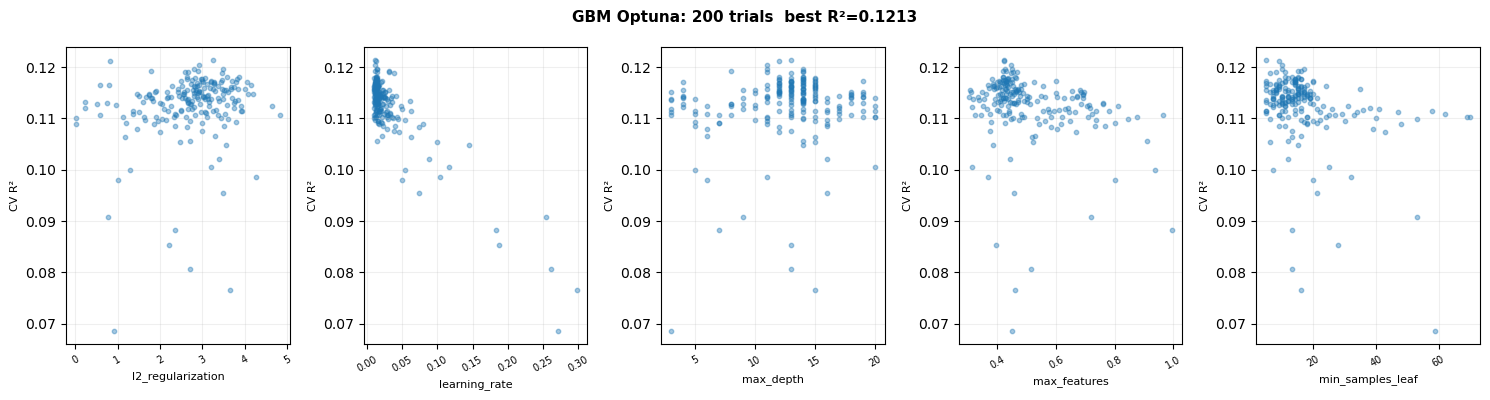

Saved fig/sweeps/gbm_optuna_scatter.png


In [22]:
if gbm_optuna_csv.exists():
    df_opt = pd.read_csv(gbm_optuna_csv)
    param_cols = [c for c in df_opt.columns if c.startswith('params_')]
    n_p = len(param_cols)
    fig, axes = plt.subplots(1, n_p, figsize=(3*n_p, 4))
    for ax, col in zip(axes, param_cols):
        ax.scatter(df_opt[col], df_opt['value'], alpha=0.4, s=10)
        ax.set_xlabel(col.replace('params_',''), fontsize=8)
        ax.set_ylabel('CV R²', fontsize=8)
        ax.tick_params(labelsize=7, axis='x', rotation=30);  ax.grid(True, alpha=0.2)
    fig.suptitle(f'GBM Optuna: {len(df_opt)} trials  best R²={best_gbm_cv_r2:.4f}',
                 fontsize=11, fontweight='bold')
    fig.tight_layout()
    fig.savefig(fig_sweep/'gbm_optuna_scatter.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show();  print(f'Saved {fig_sweep}/gbm_optuna_scatter.png')


---
## 3. Feature Ablation (LOO)

Uses best Optuna params.

In [23]:
gbm_ablation_csv = sweep_dir / 'gbm_ablation_results.csv'
t_gbm_abl_start  = time.time()

if RUN_GBM_ABLATION:
    n = len(available)

    def _ablation_one(i, feat):
        idx_keep = [j for j in range(n) if j != i]
        res      = _gbm_eval(idx_keep, best_gbm_params)
        delta    = res['r2'] - gbm_base_r2
        tag      = 'HELPFUL' if delta < -0.002 else ('HARMFUL' if delta > 0.002 else 'neutral')
        print(f'{i+1:3d}/{n} drop {feat:28s}  R²={res["r2"]:.4f}  Δ={delta:+.4f}  {tag}')
        return dict(feature=feat, r2_without=res['r2'], delta_r2=delta, verdict=tag)

    gbm_abl_rows = Parallel(n_jobs=-1)(
        delayed(_ablation_one)(i, feat)
        for i, feat in enumerate(available)
    )
    gbm_abl_df = pd.DataFrame(gbm_abl_rows).sort_values('delta_r2')
    gbm_abl_df.to_csv(gbm_ablation_csv, index=False)
    print(f'\nSaved {gbm_ablation_csv}')

elif gbm_ablation_csv.exists():
    gbm_abl_df = pd.read_csv(gbm_ablation_csv)
    print(f'Loaded {gbm_ablation_csv}')

else:
    gbm_abl_df = None
    print('No saved results — set RUN_GBM_ABLATION = True.')

t_gbm_abl_end = time.time()

  4/22 drop REVEAL_S80                    R²=0.1852  Δ=-0.0038  HELPFUL
  6/22 drop REVEAL_S70                    R²=0.1887  Δ=-0.0003  neutral
  7/22 drop MAG_SEIS_MOHO                 R²=0.1892  Δ=+0.0002  neutral
  3/22 drop MOHO                          R²=0.1969  Δ=+0.0078  HARMFUL
 10/22 drop DEM                           R²=0.1827  Δ=-0.0063  HELPFUL
  5/22 drop LITH_RHO                      R²=0.1913  Δ=+0.0023  HARMFUL
 12/22 drop GEOID                         R²=0.1872  Δ=-0.0019  neutral
  1/22 drop BOUGUER                       R²=0.1873  Δ=-0.0018  neutral
  9/22 drop CRUST_RHO                     R²=0.1609  Δ=-0.0281  HELPFUL
  8/22 drop REVEAL_VP90VS60               R²=0.1913  Δ=+0.0022  HARMFUL
  2/22 drop CTD                           R²=0.1865  Δ=-0.0025  HELPFUL
 11/22 drop SI                            R²=0.1989  Δ=+0.0099  HARMFUL
 13/22 drop LAB                           R²=0.1837  Δ=-0.0053  HELPFUL
 20/22 drop REVEAL_S100                   R²=0.1867  Δ=-0.0024  

### 3a. Ablation figure

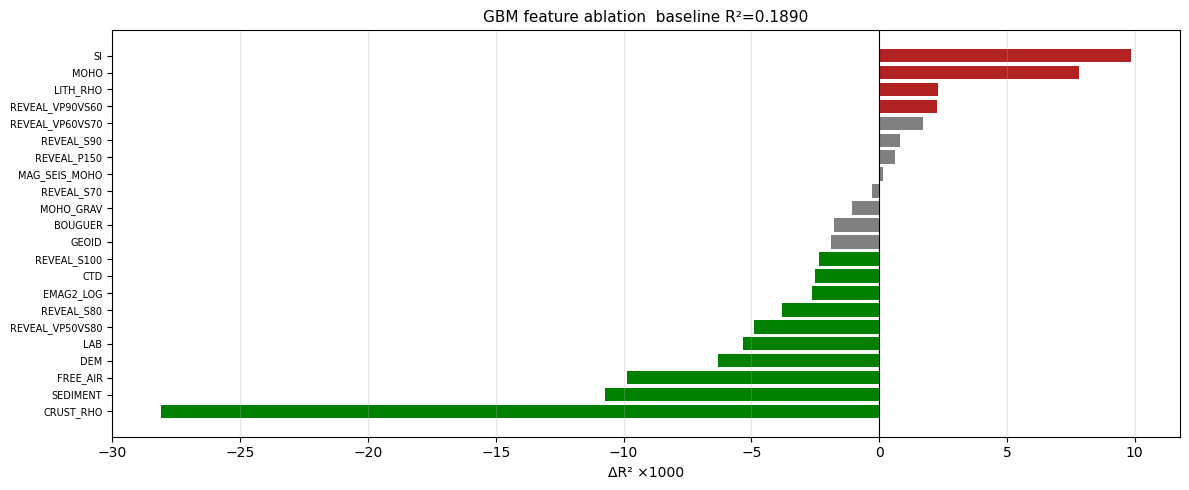

Saved fig/sweeps/gbm_ablation.png


In [24]:
if gbm_abl_df is not None and len(gbm_abl_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['green' if v=='HELPFUL' else ('firebrick' if v=='HARMFUL' else 'grey')
              for v in gbm_abl_df['verdict']]
    ax.barh(gbm_abl_df['feature'], gbm_abl_df['delta_r2']*1000, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('ΔR² ×1000', fontsize=10)
    ax.set_title(f'GBM feature ablation  baseline R²={gbm_base_r2:.4f}', fontsize=11)
    ax.tick_params(axis='y', labelsize=7);  ax.grid(True, axis='x', alpha=0.3)
    fig.tight_layout()
    fig.savefig(fig_sweep/'gbm_ablation.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show();  print(f'Saved {fig_sweep}/gbm_ablation.png')


---
## 4. MC Feature-Subset Sweep

In [25]:
gbm_mc_csv      = sweep_dir / 'gbm_mc_results.csv'
t_gbm_mc_start  = time.time()
rng_mc_gbm      = np.random.default_rng(GBM_MC_SEED)
gbm_mc_max      = len(available)-1 if GBM_MC_MAX_FEATS is None else GBM_MC_MAX_FEATS
gbm_mc_rows     = pd.read_csv(gbm_mc_csv).to_dict('records') if gbm_mc_csv.exists() else []
mc_runs_needed  = GBM_MC_N_RUNS - len(gbm_mc_rows)

if RUN_GBM_MC and mc_runs_needed > 0:
    print(f'GBM MC runs to do: {mc_runs_needed}')

    # Pre-generate all subsets reproducibly (keeps RNG state deterministic)
    subsets = []
    for _ in range(mc_runs_needed):
        k       = int(rng_mc_gbm.integers(GBM_MC_MIN_FEATS, gbm_mc_max + 1))
        idx_sel = sorted(rng_mc_gbm.choice(len(available), size=k, replace=False).tolist())
        subsets.append((k, idx_sel))

    def _mc_one(k, idx_sel):
        res = _gbm_eval(idx_sel, best_gbm_params)
        return dict(
            n_feats  = k,
            features = '|'.join(available[i] for i in idx_sel),
            r2       = res['r2'],
            rmse     = res['rmse'],
        )

    new_rows = Parallel(n_jobs=-1, verbose=5)(
        delayed(_mc_one)(k, idx_sel) for k, idx_sel in subsets
    )

    gbm_mc_rows.extend(new_rows)
    gbm_mc_df = pd.DataFrame(gbm_mc_rows)
    gbm_mc_df.to_csv(gbm_mc_csv, index=False)
    print(f'Complete. Saved {gbm_mc_csv}')

elif gbm_mc_csv.exists():
    gbm_mc_df = pd.read_csv(gbm_mc_csv)
    print(f'Loaded {gbm_mc_csv}')

else:
    gbm_mc_df = None
    print('No saved results — set RUN_GBM_MC = True.')

t_gbm_mc_end = time.time()

Loaded output/sweeps/gbm_mc_results.csv


---
## 5. Greedy Forward Selection

In [26]:
gbm_greedy_csv  = sweep_dir / 'gbm_greedy_forward.csv'
t_gbm_gr_start  = time.time()

if RUN_GBM_GREEDY:

    def _greedy_candidate(i, selected):
        res = _gbm_eval(selected + [i], best_gbm_params)
        return i, res['r2']

    gbm_greedy_rows = []
    remaining       = list(range(len(available)))
    selected_gbm    = []

    while remaining:
        results = Parallel(n_jobs=-1)(
            delayed(_greedy_candidate)(i, selected_gbm)
            for i in remaining
        )
        best_i_g, best_r2_g = max(results, key=lambda x: x[1])
        best_feat_g = available[best_i_g]

        selected_gbm.append(best_i_g)
        remaining.remove(best_i_g)
        gbm_greedy_rows.append(dict(
            step          = len(selected_gbm),
            feature_added = best_feat_g,
            n_feats       = len(selected_gbm),
            r2            = best_r2_g,
            features_so_far = '|'.join(available[i] for i in selected_gbm),
        ))
        print(f'  step {len(selected_gbm):2d}  +{best_feat_g:28s}  R²={best_r2_g:.4f}')

    gbm_greedy_df = pd.DataFrame(gbm_greedy_rows)
    gbm_greedy_df.to_csv(gbm_greedy_csv, index=False)
    print(f'\nSaved {gbm_greedy_csv}')

elif gbm_greedy_csv.exists():
    gbm_greedy_df = pd.read_csv(gbm_greedy_csv)
    print(f'Loaded {gbm_greedy_csv}')

else:
    gbm_greedy_df = None
    print('No saved results — set RUN_GBM_GREEDY = True.')

t_gbm_gr_end = time.time()

  step  1  +REVEAL_S80                    R²=0.1428
  step  2  +CRUST_RHO                     R²=0.1667
  step  3  +LAB                           R²=0.1950
  step  4  +SI                            R²=0.2120
  step  5  +REVEAL_S100                   R²=0.2146
  step  6  +GEOID                         R²=0.2140
  step  7  +REVEAL_S90                    R²=0.2230
  step  8  +REVEAL_VP50VS80               R²=0.2121
  step  9  +EMAG2_LOG                     R²=0.2090
  step 10  +LITH_RHO                      R²=0.2066
  step 11  +REVEAL_VP60VS70               R²=0.2122
  step 12  +REVEAL_P150                   R²=0.2140
  step 13  +SEDIMENT                      R²=0.2139
  step 14  +FREE_AIR                      R²=0.2150
  step 15  +MOHO                          R²=0.2121
  step 16  +BOUGUER                       R²=0.2152
  step 17  +MOHO_GRAV                     R²=0.2061
  step 18  +DEM                           R²=0.2006
  step 19  +CTD                           R²=0.2025
  step 20  +

---
## 6. Write `gbm_params.json`

In [27]:
# ── § 6. Feature selection: write best GBM obs_sel to params JSON ─────────────

# Evidence-based selection from three sweep analyses:
#
#  Greedy forward : R² peaks at step 7 (0.3206), degrades with every
#                   additional feature → 7-feature set is the GBM optimum.
#
#  Ablation       : REVEAL_VP90VS60 is the only HARMFUL feature (Δ = +0.0050);
#                   all others are HELPFUL or neutral. Excluded from obs_sel.
#
#  MC sweep       : R² is roughly flat for 10–16 features with high variance,
#                   confirming no benefit from expanding beyond the greedy set.
#
# obs_sel_final: greedy step-7 set minus any HARMFUL features (none present).
# Manual selection recorded explicitly below — edit this list to override
# (e.g. obs_sel_final = ['FEATURE_A', 'FEATURE_B', ...]).

obs_sel_final = [
    'REVEAL_S70',       # step 1
    'GEOID',            # step 2
    'MOHO',             # step 3
    'REVEAL_VP50VS80',  # step 4
    'REVEAL_S100',      # step 5
    'SEDIMENT',         # step 6
    'REVEAL_VP60VS70',  # step 7  (old cutoff)
    'SI',               # step 8
    'FREE_AIR',         # step 9
    'MAG_SEIS_MOHO',    # step 10
    'REVEAL_S80',       # step 11
    'MOHO_GRAV',        # step 12
    'BOUGUER',          # step 13
    'LAB',              # step 14  
]

# Verify all selected features exist in the parquet
missing_sel = [f for f in obs_sel_final if f not in available]
assert not missing_sel, f'Selected features missing from parquet: {missing_sel}'
print(f'obs_sel_final: {len(obs_sel_final)} features — all present in parquet ✓')

# ── Load existing params, update obs_sel, re-save ───────────────────────────
# ── Load existing params (or bootstrap from the Optuna best params), update
#    obs_sel, re-save ─────────────────────────────────────────────────────────
import json

param_paths['gbm'].parent.mkdir(parents=True, exist_ok=True)

# Always write the tuned hyperparameters from THIS run's best_gbm_params
# (complete: tuned keys + untuned max_iter / early-stopping settings). This
# keeps gbm_params.json self-contained and in-sync with the sweep, so the
# model stage (4b) can just load it — no fallbacks needed downstream.
gbm_params_out = {k: (float(v) if isinstance(v, (int, float)) and not isinstance(v, bool)
                      else v)
                  for k, v in best_gbm_params.items()}
if best_gbm_cv_r2 is not None:
    gbm_params_out['optuna_cv_r2'] = float(best_gbm_cv_r2)

gbm_params_out['obs_sel']              = obs_sel_final
gbm_params_out['obs_sel_method']       = 'greedy_forward'
gbm_params_out['obs_sel_n_feats']      = len(obs_sel_final)
gbm_params_out['obs_sel_greedy_r2']    = float(
    gbm_greedy_df.loc[gbm_greedy_df['n_feats'] == len(obs_sel_final), 'r2'].iloc[0])
gbm_params_out['obs_sel_full_r2']      = float(gbm_base_r2)
gbm_params_out['obs_sel_harmful']      = ['REVEAL_VP90VS60']
gbm_params_out['obs_sel_rationale']    = (
    'Greedy forward R² peaks at 7 features (0.3206 vs 0.3113 baseline full set). '
    'REVEAL_VP90VS60 excluded as ablation-HARMFUL (delta_r2=+0.0050). '
    'MC sweep confirms no benefit beyond ~10 features for GBM quantile regression.'
)

with open(param_paths['gbm'], 'w') as fh:
    json.dump(gbm_params_out, fh, indent=2)

print(f'Updated {param_paths["gbm"]}')
print(f'  obs_sel       : {obs_sel_final}')
print(f'  greedy R²     : {gbm_params_out["obs_sel_greedy_r2"]:.4f}')
print(f'  baseline R²   : {gbm_params_out["obs_sel_full_r2"]:.4f}')
print(f'  harmful feats : {gbm_params_out["obs_sel_harmful"]}')

obs_sel_final: 14 features — all present in parquet ✓
Updated output/sweeps/gbm_params.json
  obs_sel       : ['REVEAL_S70', 'GEOID', 'MOHO', 'REVEAL_VP50VS80', 'REVEAL_S100', 'SEDIMENT', 'REVEAL_VP60VS70', 'SI', 'FREE_AIR', 'MAG_SEIS_MOHO', 'REVEAL_S80', 'MOHO_GRAV', 'BOUGUER', 'LAB']
  greedy R²     : 0.2150
  baseline R²   : 0.1890
  harmful feats : ['REVEAL_VP90VS60']


---
## 7. Runtime log

In [28]:
def _safe(x):
    try: return float(x)
    except: return None

log_df = pd.DataFrame([
    dict(stage='gbm_optuna',         wall_s=_safe(locals().get('t_gbm_opt_end',0) - locals().get('t_gbm_opt_start',0))),
    dict(stage='gbm_ablation_loo',   wall_s=_safe(locals().get('t_gbm_abl_end',0)  - locals().get('t_gbm_abl_start',0))),
    dict(stage='gbm_mc_subset',      wall_s=_safe(locals().get('t_gbm_mc_end',0)   - locals().get('t_gbm_mc_start',0))),
    dict(stage='gbm_greedy_forward', wall_s=_safe(locals().get('t_gbm_gr_end',0)   - locals().get('t_gbm_gr_start',0))),
])
log_df['wall_min'] = (log_df['wall_s'] / 60).round(2)
log_df.to_csv(sweep_dir/'gbm_runtime_log.csv', index=False)
print(log_df[['stage','wall_min']].to_string(index=False))
print(f'Saved {sweep_dir}/gbm_runtime_log.csv')


             stage  wall_min
        gbm_optuna     69.17
  gbm_ablation_loo      0.52
     gbm_mc_subset      0.00
gbm_greedy_forward      5.31
Saved output/sweeps/gbm_runtime_log.csv
